# Exploratory Data Analysis

**Question:** How did Stack Overflow question volume and developers' reported habits change as generative AI spread?

We explore three datasets:
1. **Stack Overflow new questions per month**, January 2018 to August 2026 (Stack Exchange API)
2. **ChatGPT weekly active users**, 11 public announcements from OpenAI and news coverage
3. **Stack Overflow Developer Survey** 2023, 2024 and 2025 (AI use and how often people visit Stack Overflow)

Each section follows the same steps: the questions we are asking, the code, and our interpretation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from src.download import download_developer_survey, download_stackoverflow_questions, save_chatgpt_weekly_users
from src.clean import clean_stackoverflow_questions, clean_chatgpt_weekly_users, clean_developer_survey

CLEAN = ROOT / "data" / "clean"

FIG = ROOT / "outputs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
download_stackoverflow_questions()
save_chatgpt_weekly_users()
download_developer_survey()

saved stackoverflow_monthly_questions.csv
saved chatgpt_weekly_users.csv
saved survey/survey_2023_results.csv
saved survey/survey_2024_results.csv
saved survey/survey_2025_results.csv


In [3]:
clean_stackoverflow_questions()
clean_chatgpt_weekly_users()
clean_developer_survey()

saved stackoverflow_monthly_questions.csv (104 months)
saved chatgpt_weekly_users.csv (11 announcements)
saved survey_ai_and_stackoverflow.csv (203812 respondents)


In [4]:
so  = pd.read_csv(CLEAN / "stackoverflow_monthly_questions.csv", parse_dates=["month"])
wau = pd.read_csv(CLEAN / "chatgpt_weekly_users.csv", parse_dates=["date", "month"])
sv  = pd.read_csv(CLEAN / "survey_ai_and_stackoverflow.csv")

## 1. Data Structure

### Questions we are asking:
* What are the dimensions of each dataset (number of rows and columns)?
* What are the data types of the variables (dates, numbers, categories)?
* Are there any missing values, and if so, how are they represented?

In [5]:
for name, df in [("stackoverflow_monthly_questions", so), ("chatgpt_weekly_users", wau), ("survey_ai_and_stackoverflow", sv)]:
    print(f"--- {name} {df.shape}")
    print(pd.DataFrame({"dtype": df.dtypes, "missing": df.isnull().sum()}).to_string())
    print(df.head(3).to_string(index=False))
    print()

--- stackoverflow_monthly_questions (104, 2)
                    dtype  missing
month      datetime64[ns]        0
questions           int64        0
     month  questions
2018-01-01     160440
2018-02-01     153055
2018-03-01     172864

--- chatgpt_weekly_users (11, 5)
                                dtype  missing
date                   datetime64[ns]        0
month                  datetime64[ns]        0
weekly_users_millions           int64        0
qualifier                      object        0
source                         object        0
      date      month  weekly_users_millions qualifier                                                                                     source
2023-11-06 2023-11-01                    100     about https://techcrunch.com/2023/11/06/openais-chatgpt-now-has-100-million-weekly-active-users/
2024-08-29 2024-08-01                    200 more than            https://www.axios.com/2024/08/29/openai-chatgpt-200-million-weekly-active-users
2024-10-

### Interpretation

**Stack Overflow questions:** 104 rows (one per month, January 2018 to August 2026) and 2 columns: `month` is a date and `questions` is a whole number. No missing values.

**ChatGPT weekly users:** only 11 rows, one per public announcement from November 2023 to August 2026. `weekly_users_millions` is a number; `qualifier` ("about", "more than", "on track for") and `source` (the article link) are text. No missing values. The announcements are unevenly spaced (1 to 10 months apart), so this is not a regular monthly series.

**Developer survey:** 203,812 rows, one per respondent, across 2023, 2024 and 2025. `uses_ai` is a category ("uses AI", "plans to", "does not") and `visits_so_daily` is True/False (it shows as `object` because of the blanks). 21,212 people left the AI question blank and 24,426 left the visit question blank. Blanks stay as `NaN`; we did not fill them in.

## 2. Descriptive Statistics

### Questions we are asking:
* What are the central tendency measures (mean, median) for the numerical variables?
* What are the measures of dispersion (standard deviation, min, max)?
* What is the distribution of the variables (normal, skewed, etc.)?
* For the survey, which answers are most common each year?

In [6]:
print("Stack Overflow new questions per month")
print(so["questions"].describe().round(0).to_string())
print(f"skewness {so['questions'].skew():.2f}, kurtosis {so['questions'].kurt():.2f}")

print("\nSame measures, one row per year")
print(so.groupby(so["month"].dt.year.rename("year"))["questions"].agg(["mean", "median", "std", "min", "max"]).round(0).to_string())

print("\nChatGPT weekly users (millions)")
print(wau["weekly_users_millions"].describe().round(0).to_string())

print("\nSurvey: share of each answer by year (%, blanks left out)")
print((100 * pd.crosstab(sv["year"], sv["uses_ai"], normalize="index")).round(1).to_string())
print((100 * pd.crosstab(sv["year"], sv["visits_so_daily"], normalize="index")).round(1).to_string())

Stack Overflow new questions per month
count       104.0
mean      92988.0
std       59145.0
min        1125.0
25%       31814.0
50%      113191.0
75%      145340.0
max      186391.0
skewness -0.33, kurtosis -1.43

Same measures, one row per year
          mean    median      std     min     max
year                                             
2018  156317.0  159198.0  10732.0  132168  172864
2019  146310.0  148870.0   8758.0  132497  161051
2020  154587.0  147426.0  18043.0  133867  186391
2021  127857.0  126430.0  10512.0  112078  148706
2022  111276.0  111928.0   7179.0   96194  123276
2023   65648.0   63062.0  16517.0   42289   96638
2024   33203.0   31690.0  10555.0   17924   47577
2025    9147.0    7188.0   4799.0    4195   18183
2026    2330.0    2310.0    956.0    1125    3676

ChatGPT weekly users (millions)
count      11.0
mean      550.0
std       322.0
min       100.0
25%       275.0
50%       500.0
75%       850.0
max      1000.0

Survey: share of each answer by year (%, 

### Interpretation

#### Central Tendency
Across all 104 months, the mean is about 93,000 questions and the median is about 113,000. The mean is below the median because the recent, very low months pull it down. Neither number describes a "typical" month: the average month fell from about 156,000 questions in 2018 to 111,000 in 2022, then to 66,000 in 2023, 33,000 in 2024, 9,100 in 2025 and 2,300 in 2026 (January to August only).

#### Dispersion
The standard deviation over all months is about 59,000, more than half the mean, because the data covers two very different periods. The busiest month had about 186,000 questions (May 2020) and the quietest about 1,100 (August 2026). Within a single year before 2023, the standard deviation was only about 7,000 to 18,000; 2020 is the widest because of the COVID lockdown spike.

#### Distribution
Skewness is -0.33 (slightly left-skewed, from the low recent months) and kurtosis is -1.43 (flatter than a normal curve). This is what two groups of months look like when mixed together, which the histogram in Section 5 confirms.

#### ChatGPT and the Survey
ChatGPT's announced weekly users go from 100 million to 1,000 million, with a median of 500 million. In the survey (blanks left out), the share who use AI rose from 44.4% in 2023 to 61.8% in 2024 and 78.5% in 2025, while "plans to" fell from 25.8% to 5.3% and "does not" from 29.8% to 16.2%. The share who visit Stack Overflow daily fell from 39.1% to 37.3% to 24.8%.

## 3. Data Quality

### Questions we are asking:
* Are there any duplicated rows, missing months or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?

In [7]:
all_months = pd.date_range("2018-01-01", "2026-08-01", freq="MS")
print(f"Stack Overflow: {so['month'].duplicated().sum()} duplicated months, "
      f"{len(all_months.difference(so['month']))} missing months, "
      f"{(so['questions'] <= 0).sum()} months with zero questions")
print("\nBusiest months:")
print(so.nlargest(5, "questions").to_string(index=False))

print(f"\nChatGPT: {wau['date'].duplicated().sum()} duplicated dates, "
      f"numbers never go down: {wau['weekly_users_millions'].is_monotonic_increasing}")
print(wau["qualifier"].value_counts().to_string())

print(f"\nSurvey: {sv.duplicated().sum()} rows repeat an earlier row")
print(pd.crosstab(sv["year"], sv["uses_ai"].fillna("blank")).to_string())
print(pd.crosstab(sv["year"], sv["visits_so_daily"].fillna("blank")).to_string())

Stack Overflow: 0 duplicated months, 0 missing months, 0 months with zero questions

Busiest months:
     month  questions
2020-05-01     186391
2020-04-01     182833
2018-03-01     172864
2020-06-01     171836
2018-05-01     167431

ChatGPT: 0 duplicated dates, numbers never go down: True
qualifier
more than       6
about           4
on track for    1

Survey: 203778 rows repeat an earlier row
uses_ai  blank  does not  plans to  uses AI
year                                       
2023      1211     26221     22710    39042
2024      4530     14837      8408    37662
2025     15471      5454      1797    26469
visits_so_daily  False   True  blank
year                                
2023             53064  34076   2044
2024             37351  22185   5901
2025             24594   8116  16481


### Interpretation

#### Duplicates and Gaps
The Stack Overflow data is complete: no duplicated months, no missing months, and no month with zero questions. The ChatGPT data has no duplicated announcement dates.

The survey shows 203,778 "repeated" rows. This is expected, not an error: each row is a different respondent, and with only three columns and a few possible answers, many people give the same answers. We keep all of them.

#### Outliers
Three of the five busiest months are May 2020 (about 186,000), April 2020 (183,000) and June 2020 (172,000), the COVID lockdown months. They are real, not errors, so we keep them, but we flag them in Section 6 so they do not distort the trend.

#### Do the Values Make Sense?
ChatGPT's announced users never go down, which matches the public story. But these are rounded public claims, not measurements: 6 say "more than", 4 say "about", and 1 (August 2025, 700 million) says "on track for", which is a forecast. We use them for timing and direction only, not for exact calculations.

In the survey, the three answer groups are the same every year, so the cleaning made the years comparable. Blanks, however, grew a lot: 1,211 of 89,184 people (1%) skipped the AI question in 2023, but 15,471 of 49,191 (31%) skipped it in 2025. If the people who skipped are different from those who answered, the 2025 numbers could be off, so we treat them with some caution.

## 4. Variable Relationships

### Questions we are asking:
* Is there any correlation between ChatGPT's growth and the number of Stack Overflow questions?
* Are there any noticeable patterns or trends over time?
* How is AI use (a category) related to visiting Stack Overflow daily?

In [8]:
matched = wau.merge(so, on="month")
print(f"{len(matched)} months have both a ChatGPT number and a Stack Overflow count")
print("Pearson correlation:")
print(matched[["weekly_users_millions", "questions"]].corr().round(2).to_string())
print("\nSpearman (rank) correlation:")
print(matched[["weekly_users_millions", "questions"]].corr(method="spearman").round(2).to_string())

11 months have both a ChatGPT number and a Stack Overflow count
Pearson correlation:
                       weekly_users_millions  questions
weekly_users_millions                   1.00      -0.89
questions                              -0.89       1.00

Spearman (rank) correlation:
                       weekly_users_millions  questions
weekly_users_millions                   1.00      -0.99
questions                              -0.99       1.00


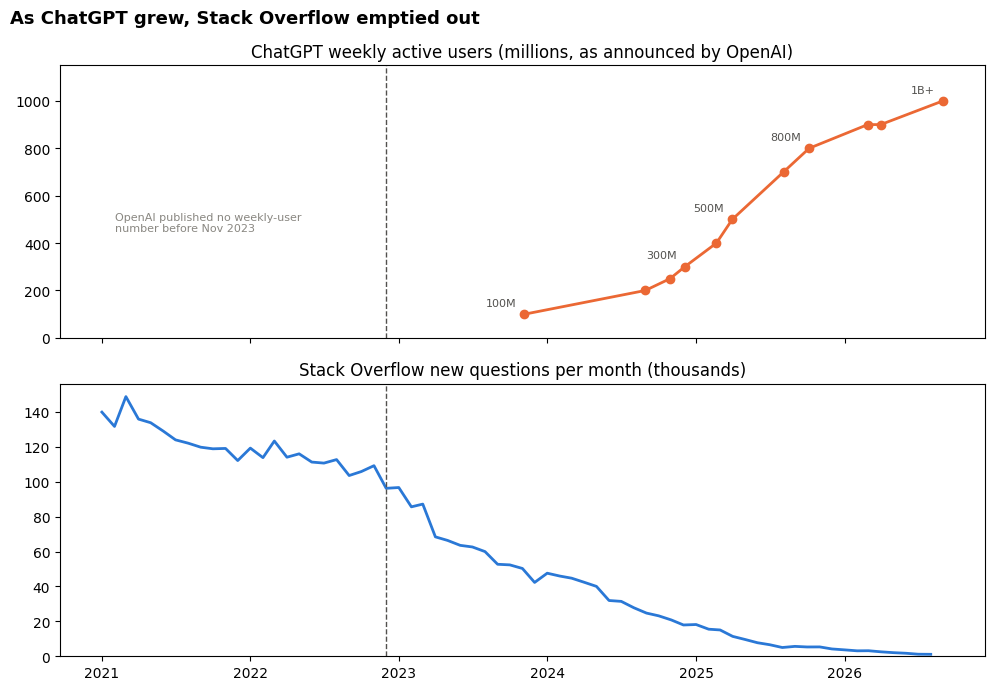

      date  weekly_users_millions  questions
2023-11-06                    100      50285
2024-08-29                    200      27786
2024-10-29                    250      23167
2024-12-04                    300      17924
2025-02-20                    400      15506
2025-03-31                    500      15076
2025-08-04                    700       5022
2025-10-06                    800       5331
2026-02-27                    900       3125
2026-03-31                    900       3177
2026-08-31                   1000       1125


In [9]:
def plot_chatgpt_vs_stackoverflow(so, wau):
    CHATGPT = pd.Timestamp("2022-11-30")
    recent = so[so["month"] >= "2021-01-01"]

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    top.plot(wau["date"], wau["weekly_users_millions"], color="#eb6834", marker="o", lw=2)
    for _, row in wau.iloc[[0, 3, 5, 7, -1]].iterrows():
        n = row["weekly_users_millions"]
        top.annotate("1B+" if n >= 1000 else f"{n}M", (row["date"], n), xytext=(-6, 6),
                     textcoords="offset points", ha="right", fontsize=8, color="#52514e")
    top.text(pd.Timestamp("2021-02-01"), 450, "OpenAI published no weekly-user\nnumber before Nov 2023",
             fontsize=8, color="#898781")
    top.set_ylim(0, 1150)
    top.set_title("ChatGPT weekly active users (millions, as announced by OpenAI)")

    bottom.plot(recent["month"], recent["questions"] / 1e3, color="#2a78d6", lw=2)
    bottom.set_ylim(0, None)
    bottom.set_title("Stack Overflow new questions per month (thousands)")

    for ax in (top, bottom):
        ax.axvline(CHATGPT, color="#52514e", lw=1, ls="--")
    fig.suptitle("As ChatGPT grew, Stack Overflow emptied out", x=0.01, ha="left", fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(FIG / "chatgpt_vs_stackoverflow.png", dpi=150, bbox_inches="tight")
    plt.show()

    matched = wau.merge(so, on="month")[["date", "weekly_users_millions", "questions"]]
    print(matched.to_string(index=False))

plot_chatgpt_vs_stackoverflow(so=so, wau=wau)

uses_ai  does not  uses AI
year                      
2023         35.8     40.7
2024         36.3     37.4
2025         31.3     23.2


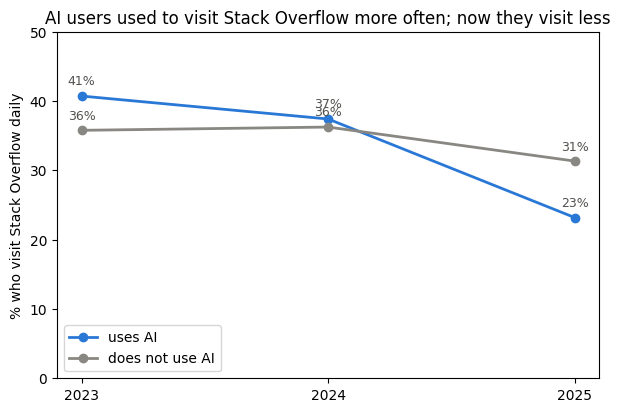

In [10]:
def plot_daily_visits_by_ai_use(sv):
    answered = sv.dropna(subset=["uses_ai", "visits_so_daily"])
    answered = answered[answered["uses_ai"] != "plans to"]
    daily = answered.groupby(["year", "uses_ai"])["visits_so_daily"].apply(lambda s: s.astype(bool).mean() * 100).unstack()
    print(daily.round(1).to_string())

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for group, color, label in [("uses AI", "#2a78d6", "uses AI"), ("does not", "#898781", "does not use AI")]:
        ax.plot(daily.index, daily[group], color=color, marker="o", lw=2, label=label)
        for year, v in daily[group].items():
            ax.annotate(f"{v:.0f}%", (year, v), xytext=(0, 8), textcoords="offset points", ha="center",
                        fontsize=9, color="#52514e")
    ax.set_xticks(daily.index)
    ax.set_ylim(0, 50)
    ax.set_ylabel("% who visit Stack Overflow daily")
    ax.set_title("AI users used to visit Stack Overflow more often; now they visit less")
    ax.legend(loc="lower left")
    fig.savefig(FIG / "stackoverflow_daily_visits_by_ai_use.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_daily_visits_by_ai_use(sv=sv)

### Interpretation

#### Correlation
For the 11 months with both numbers, the Pearson correlation between ChatGPT weekly users and Stack Overflow questions is -0.89, and the Spearman (rank) correlation is -0.99: almost every time ChatGPT announced a higher number, Stack Overflow had fewer questions.

This does not prove that one caused the other. Both series move steadily with time, and any two series that trend in opposite directions over the same years will show a strong negative correlation. With only 11 points, the number is also fragile.

#### Patterns Over Time
The two-panel chart shows the pattern: ChatGPT grew from 100 million to 1 billion weekly users while monthly questions in the same months fell from about 50,000 to about 1,100. The Stack Overflow decline also started before ChatGPT (Section 5).

#### AI Use and Daily Visits
In 2023, developers who use AI were more likely to visit Stack Overflow daily than those who do not (40.7% vs. 35.8%). By 2025 this had reversed: 23.2% vs. 31.3%. The drop is concentrated among AI users (-17.5 points), while non-users fell only 4.5 points. Each survey year is a different group of people, so this compares groups, not the same people changing their habits.

## 5. Data Visualization

### Questions we are asking:
* How can the variables be visualized effectively (histograms, box plots, line charts, bar charts)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?

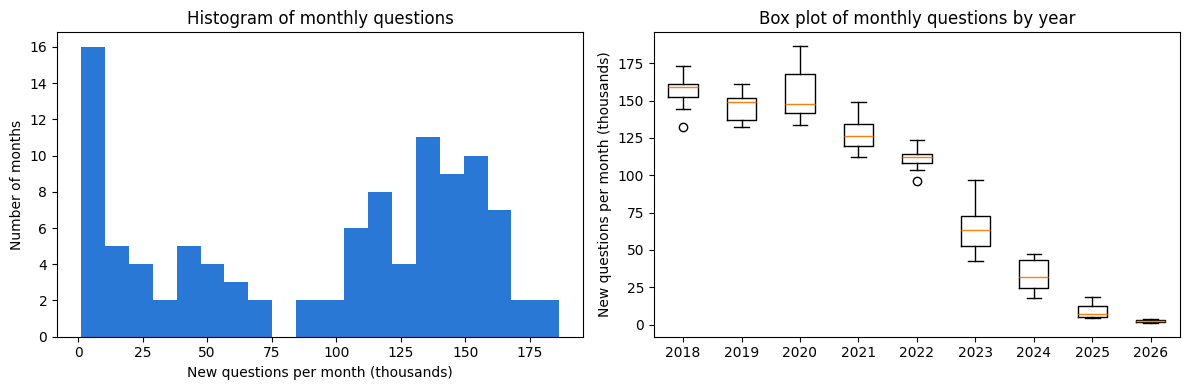

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

left.hist(so["questions"] / 1e3, bins=20, color="#2a78d6")
left.set_xlabel("New questions per month (thousands)")
left.set_ylabel("Number of months")
left.set_title("Histogram of monthly questions")

years = sorted(so["month"].dt.year.unique())
right.boxplot([so.loc[so["month"].dt.year == y, "questions"] / 1e3 for y in years], tick_labels=years)
right.set_ylabel("New questions per month (thousands)")
right.set_title("Box plot of monthly questions by year")

plt.tight_layout()
fig.savefig(FIG / "stackoverflow_questions_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

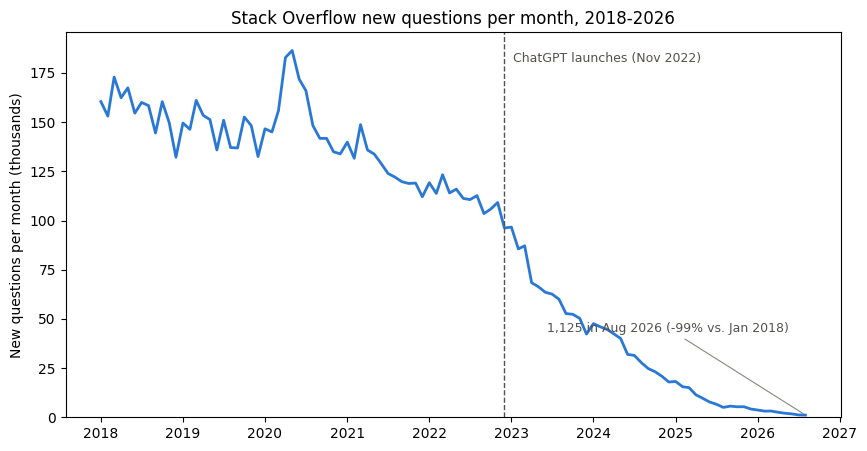

In [12]:
def plot_stackoverflow_questions():
    CHATGPT = pd.Timestamp("2022-11-30")
    first, last = so.iloc[0], so.iloc[-1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(so["month"], so["questions"] / 1e3, color="#2a78d6", lw=2)

    ax.axvline(CHATGPT, color="#52514e", lw=1, ls="--")
    ax.annotate("ChatGPT launches (Nov 2022)", (CHATGPT, 0.95), xycoords=("data", "axes fraction"),
                xytext=(6, 0), textcoords="offset points", va="top", fontsize=9, color="#52514e")

    pct = 100 * (last["questions"] / first["questions"] - 1)
    ax.annotate(f"{last['questions']:,} in {last['month']:%b %Y} ({pct:.0f}% vs. {first['month']:%b %Y})",
                (last["month"], last["questions"] / 1e3), xytext=(-12, 60), textcoords="offset points",
                ha="right", fontsize=9, color="#52514e",
                arrowprops=dict(arrowstyle="-", color="#898781", lw=0.8))

    ax.set_ylim(0, None)
    ax.set_ylabel("New questions per month (thousands)")
    ax.set_title("Stack Overflow new questions per month, 2018-2026")
    fig.savefig(FIG / "stackoverflow_questions.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_stackoverflow_questions()

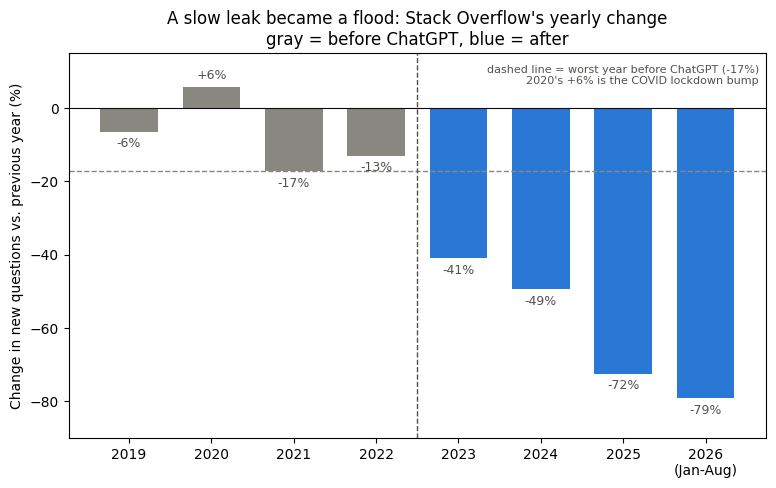

In [13]:
def plot_stackoverflow_year_change(so):
    full = so[so["month"].dt.year <= 2025].groupby(so["month"].dt.year)["questions"].sum()
    yoy = (100 * (full / full.shift() - 1)).dropna()
    ytd_2026 = so[so["month"] >= "2026-01-01"]["questions"].sum()
    ytd_2025 = so[(so["month"] >= "2025-01-01") & (so["month"] <= "2025-08-01")]["questions"].sum()
    yoy.loc[2026] = 100 * (ytd_2026 / ytd_2025 - 1)

    worst = yoy[yoy.index <= 2022].min()
    labels = [str(y) if y < 2026 else "2026\n(Jan-Aug)" for y in yoy.index]
    colors = ["#898781" if y <= 2022 else "#2a78d6" for y in yoy.index]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(yoy))
    ax.bar(x, yoy, color=colors, width=0.7)
    for xi, v in zip(x, yoy):
        ax.text(xi, v + (1.5 if v > 0 else -1.5), f"{v:+.0f}%", ha="center",
                va="bottom" if v > 0 else "top", fontsize=9, color="#52514e")

    ax.axhline(0, color="#0b0b0b", lw=0.8)
    ax.axhline(worst, color="#898781", lw=1, ls="--")
    ax.axvline(3.5, color="#52514e", lw=1, ls="--")

    ax.text(0.99, 0.97, f"dashed line = worst year before ChatGPT ({worst:.0f}%)\n"
                        "2020's +6% is the COVID lockdown bump",
            transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#52514e")

    ax.set_xticks(x, labels)
    ax.set_ylim(-90, 15)
    ax.set_ylabel("Change in new questions vs. previous year (%)")
    ax.set_title("A slow leak became a flood: Stack Overflow's yearly change\n"
                 "gray = before ChatGPT, blue = after")
    fig.savefig(FIG / "stackoverflow_year_change.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_stackoverflow_year_change(so=so)

year
2023    44.4
2024    61.8
2025    78.5


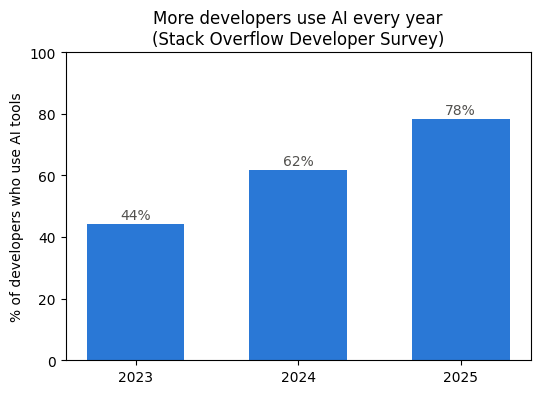

In [14]:
def plot_ai_adoption(sv):
    share = sv.dropna(subset=["uses_ai"]).groupby("year")["uses_ai"].apply(lambda s: (s == "uses AI").mean() * 100)
    print(share.round(1).to_string())

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(share.index.astype(str), share, color="#2a78d6", width=0.6)
    for x, v in enumerate(share):
        ax.text(x, v + 1.5, f"{v:.0f}%", ha="center", fontsize=10, color="#52514e")
    ax.set_ylim(0, 100)
    ax.set_ylabel("% of developers who use AI tools")
    ax.set_title("More developers use AI every year\n(Stack Overflow Developer Survey)")
    fig.savefig(FIG / "stackoverflow_survey_ai_adoption.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_ai_adoption(sv=sv)

### Interpretation

#### Histogram
The months fall into two groups: most months before 2023 sit between 100,000 and 186,000 questions, and a second pile sits below 10,000 (2025 and 2026). The 2023 and 2024 months are spread thinly in between. There is no single "normal" month, which explains the skewness and kurtosis in Section 2.

#### Box Plot by Year
The median month gets smaller every year, even in 2020, when the lockdown spike raised the mean but not the median: about 159,000 in 2018, 112,000 in 2022, 63,000 in 2023 and 7,200 in 2025. 2020 has the tallest box because of the spike. The two outlier dots are December 2018 and December 2022. December is always a quiet month (Section 6), so these are seasonal dips, not data errors.

#### Line Chart and Yearly Change
Monthly questions fell from about 160,000 in January 2018 to about 1,100 in August 2026 (-99%). The yearly bars show the decline started before ChatGPT (-6% in 2019, -17% in 2021, -13% in 2022; 2020's +6% is the lockdown bump), but every year after launch was far worse: -41% in 2023, -49% in 2024 and -72% in 2025. January to August 2026 was another 79% below the same months of 2025.

#### AI Adoption
Among developers who answered, the share who use AI tools went from 44% in 2023 to 62% in 2024 and 79% in 2025.

## 6. Feature Engineering

### Questions we are asking:
* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?

     month  questions  year month_name  year_over_year_change_pct  post_chatgpt  log_questions  rolling_12_month_median
2026-06-01       1731  2026        Jun                 -77.670279          True       7.456455                   3935.5
2026-07-01       1185  2026        Jul                 -82.107806          True       7.077498                   3426.5
2026-08-01       1125  2026        Aug                 -77.598566          True       7.025538                   3151.0

Each calendar month as % of its year's average:
month
1     105.3
2     100.8
3     111.9
4     104.4
5     104.8
6      98.1
7     100.5
8      97.9
9      93.2
10     98.7
11     97.1
12     87.3


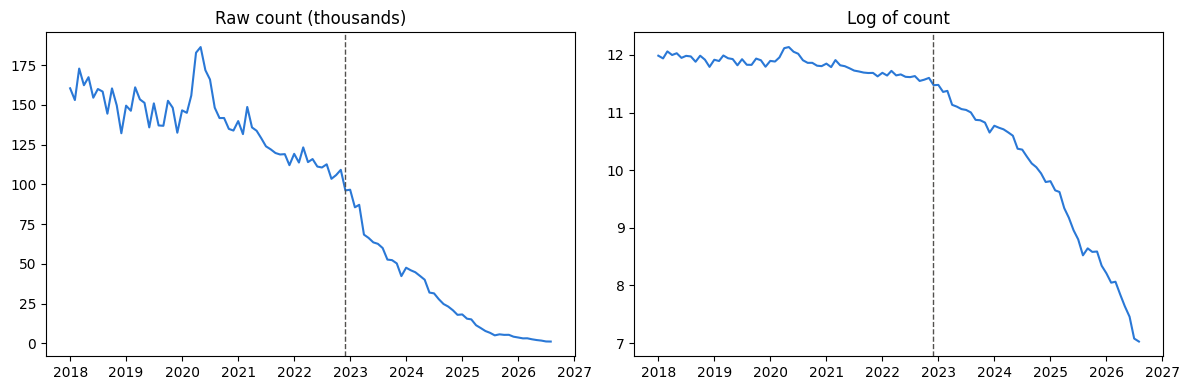

In [15]:
# Feature Engineering: the same features as src/feature_engineering.py
from src.feature_engineering import build_stackoverflow_features

features = build_stackoverflow_features()
print(features.tail(3).to_string(index=False))

# Seasonality: each calendar month as % of its year's average (2020 left out because of the COVID spike)
normal_years = features[features["year"].isin([2018, 2019, 2021, 2022])]
season = 100 * normal_years["questions"] / normal_years.groupby("year")["questions"].transform("mean")
print("\nEach calendar month as % of its year's average:")
print(season.groupby(normal_years["month"].dt.month).mean().round(1).to_string())

# Why log: on the raw scale the recent years are squashed near zero
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
left.plot(features["month"], features["questions"] / 1e3, color="#2a78d6")
left.set_title("Raw count (thousands)")
right.plot(features["month"], features["log_questions"], color="#2a78d6")
right.set_title("Log of count")
for ax in (left, right):
    ax.axvline(pd.Timestamp("2022-11-30"), color="#52514e", lw=1, ls="--")
plt.tight_layout()
fig.savefig(FIG / "log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

trend before ChatGPT: -7.7% per year
       questions   expected  gap_pct
month                               
2023      787776  1284221.0    -38.7
2024      398436  1185241.1    -66.4
2025      109763  1093890.0    -90.0
2026       18640   690657.7    -97.3


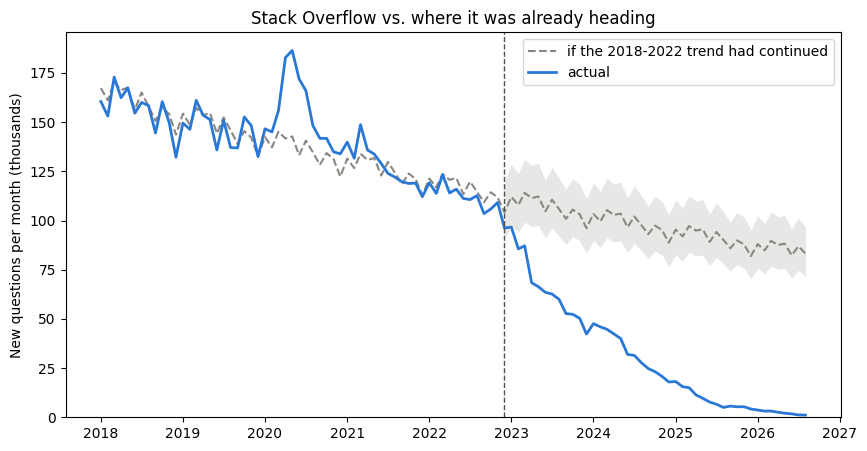

In [16]:
def plot_trend_counterfactual(so):
    CHATGPT = pd.Timestamp("2022-11-30")
    df = so.copy()
    df["log_questions"] = np.log(df["questions"])
    df["t"] = np.arange(len(df)) / 12                                           # years since Jan 2018
    df["month_of_year"] = df["month"].dt.month                                  # seasonality
    df["covid"] = df["month"].between("2020-03-01", "2020-06-01").astype(int)   # lockdown spike

    before = df[df["month"] < "2022-12-01"]
    model = smf.ols("log_questions ~ t + covid + C(month_of_year)", data=before).fit()
    pred = model.get_prediction(df.assign(covid=0)).summary_frame(alpha=0.05)
    df["expected"] = np.exp(pred["mean"])
    df["low"], df["high"] = np.exp(pred["obs_ci_lower"]), np.exp(pred["obs_ci_upper"])

    after = df[df["month"] >= "2022-12-01"]
    yearly = df[df["month"].dt.year >= 2023].groupby(df["month"].dt.year)[["questions", "expected"]].sum()
    yearly["gap_pct"] = 100 * (yearly["questions"] / yearly["expected"] - 1)
    print(f"trend before ChatGPT: {100 * (np.exp(model.params['t']) - 1):.1f}% per year")
    print(yearly.round(1).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(after["month"], after["low"] / 1e3, after["high"] / 1e3, color="#898781", alpha=0.2, lw=0)
    ax.plot(df["month"], df["expected"] / 1e3, color="#898781", ls="--", lw=1.5,
            label="if the 2018-2022 trend had continued")
    ax.plot(df["month"], df["questions"] / 1e3, color="#2a78d6", lw=2, label="actual")
    ax.axvline(CHATGPT, color="#52514e", lw=1, ls="--")
    ax.set_ylim(0, None)
    ax.set_ylabel("New questions per month (thousands)")
    ax.set_title("Stack Overflow vs. where it was already heading")
    ax.legend(loc="upper right")
    fig.savefig(FIG / "trend_counterfactual.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_trend_counterfactual(so=so)

### Interpretation

#### New Features
We reuse `build_stackoverflow_features()` from `src/feature_engineering.py`, so the EDA and the analysis use the same columns:
* `year` and `month_name`: the date split into parts, to compare years and seasons.
* `year_over_year_change_pct`: each month compared with the same month one year earlier, which removes seasonality. In August 2026, questions were about 78% below August 2025.
* `post_chatgpt`: True from December 2022 on, to split the data into before and after launch.
* `log_questions`: the log of the count (see below).
* `rolling_12_month_median`: the median of the last 12 months, which smooths out seasons and one-off spikes like COVID. It fell from about 112,000 in November 2022 to about 3,200 in August 2026.

The last two are empty for the first 11 to 12 months, because they need a year of history. The trend model above adds `t` (years since January 2018), `month_of_year` and `covid` (March to June 2020). The survey features were made during cleaning: six AI answers combined into three groups, and seven visit options into daily yes/no.

#### Seasonality (why the month matters)
In normal years (2018, 2019, 2021 and 2022), March is the busiest month, about 12% above its year's average, and December is the quietest, about 13% below. September is also low, about 7% below. A fair comparison has to compare like with like, which is why the trend model includes the month and the year-over-year feature compares each month with the same month a year earlier.

#### Log Transform (why `log_questions`)
The count shrinks from about 186,000 to about 1,100, so on the raw scale the recent years are squashed near zero. On the log scale, a steady percentage decline becomes a straight line. Before ChatGPT the log line is nearly straight with a gentle slope; after late 2022 it bends down and keeps getting steeper. So what changed is the rate of decline, not just a one-time drop.

#### The Trend Model
Fitted on the 59 months before December 2022, the old trend was a decline of 7.7% per year. Projected forward, actual questions were 38.7% below that trend in 2023, 66.4% below in 2024, 90.0% below in 2025 and 97.3% below in 2026 (January to August).

# Interpretation for Our Analysis

#### Dimensions
104 months of Stack Overflow data is enough to fit a trend with seasonality on the 59 months before ChatGPT. The ChatGPT data has only 11 points, too few to model, so we use it for timing and direction only.

#### Data Types and Missing Values
Survey answers are categories, so we compare percentages, not averages. Blanks are left out of each percentage. The 2025 survey has far more blanks (about a third of respondents), so its numbers carry more uncertainty.

#### Descriptive Statistics
The overall mean mixes two very different periods and describes neither, so we report everything by year.

#### Data Quality
The COVID spike is real, so we keep it and give it its own flag in the model. The December dips are seasonal, so the model includes the month.

#### Variable Relationships
ChatGPT growth and Stack Overflow questions are strongly negatively correlated, but both follow time, so this alone does not show cause. The survey is stronger evidence: the drop in daily visits is concentrated among AI users. Even so, each year is a different group of people, so this is still correlation, not proof.

#### Data Visualization and Feature Engineering
The decline began before ChatGPT, at about 7.7% a year. After 2022 it became far steeper: actual questions fell 39% to 97% below where the old trend was heading. ChatGPT did not start the decline, but after it launched, a slow leak became a flood.